Dost, 'kaggle.json' upload karein:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images
License(s): other
100% 105M/105M [00:00<00:00, 209MB/s] 

Found 80000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Starting Professional Training...
Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 130s 93ms/step - accuracy: 0.7031 - loss: 0.5714 - precision: 0.6994 - recall: 0.7122 - val_accuracy: 0.7475 - val_loss: 0.5231 - val_precision: 0.7592 - val_recall: 0.7249
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 128s 87ms/step - accuracy: 0.7376 - loss: 0.5324 - precision: 0.7362 - recall: 0.7404 - val_accuracy: 0.7620 - val_loss: 0.4992 - val_precision: 0.7533 - val_recall: 0.7790
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 114s 91ms/step - accuracy: 0.7486 - loss: 0.5151 - precision: 0.7475 - recall: 0.7508 - val_accuracy: 0.7641 - val_loss: 0.4896 - val_precision: 0.7539 - val_recall:

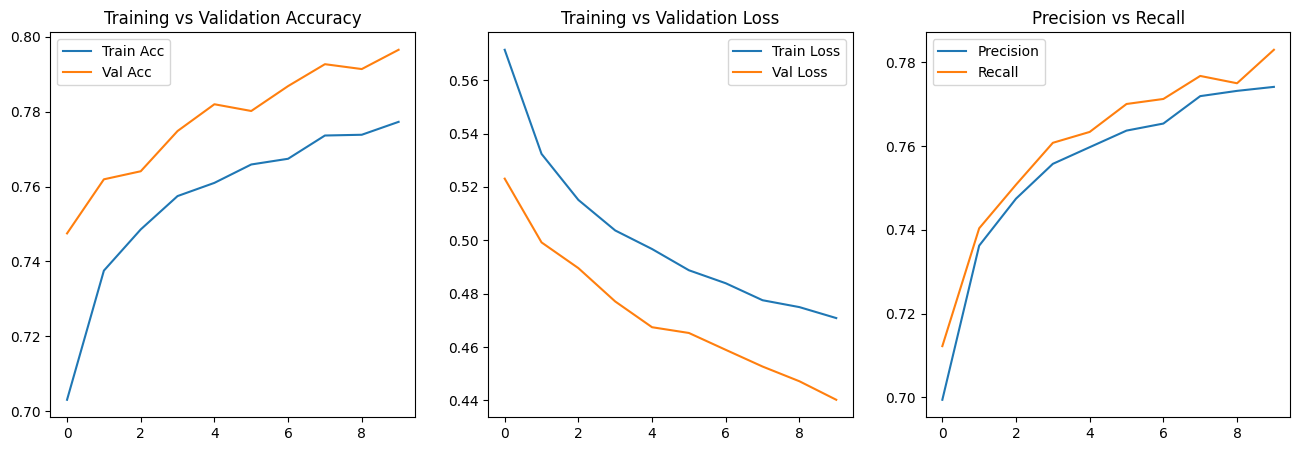


--- Generating Confusion Matrix ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 81ms/step


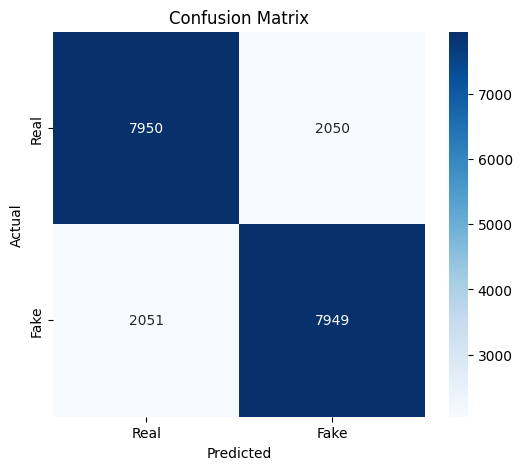


Classification Report:
               precision    recall  f1-score   support

        Real       0.79      0.80      0.79     10000
        Fake       0.79      0.79      0.79     10000

    accuracy                           0.79     20000
   macro avg       0.79      0.79      0.79     20000
weighted avg       0.79      0.79      0.79     20000



In [1]:
# ==========================================
# 1. ADVANCED LIBRARIES & DATASET SETUP
# ==========================================
import os, matplotlib.pyplot as plt, numpy as np, seaborn as sns
from google.colab import files
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from sklearn.metrics import confusion_matrix, classification_report

# Kaggle API Setup
if not os.path.exists('/root/.kaggle/kaggle.json'):
    print("Dost, 'kaggle.json' upload karein:")
    files.upload()
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

# Dataset Download & Extraction
if not os.path.exists('train'):
    !kaggle datasets download -d birdy654/cifake-real-and-ai-generated-synthetic-images
    !unzip -q cifake-real-and-ai-generated-synthetic-images.zip

# ==========================================
# 2. DATA PIPELINE (Module 6: Augmentation)
# ==========================================
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255, validation_split=0.2,
    rotation_range=15, horizontal_flip=True, brightness_range=[0.8, 1.2]
)

train_ds = datagen.flow_from_directory('train', target_size=(32, 32), batch_size=64, class_mode='binary', subset='training')
val_ds = datagen.flow_from_directory('train', target_size=(32, 32), batch_size=64, class_mode='binary', subset='validation', shuffle=False)

# ==========================================
# 3. TRANSFER LEARNING ARCHITECTURE (Module 7 & 13)
# ==========================================
base_model = tf.keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

# Compilation me explicit names set kiye hain
model.compile(
    optimizer=optimizers.Adam(0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)

# ==========================================
# 4. TRAINING WITH CALLBACKS (Module 3-4)
# ==========================================
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

print("Starting Professional Training...")
history = model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=[early_stop])

# ==========================================
# 5. ADVANCED VISUALIZATION & GRAPHS
# ==========================================
plt.figure(figsize=(16, 5))
plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training vs Validation Loss')
plt.legend()

# FIXED PLOTTING KEYS: Ab yeh bilkul sahi 'precision' aur 'recall' keys use kar raha hai
plt.subplot(1, 3, 3)
plt.plot(history.history['precision'], label='Precision')
plt.plot(history.history['recall'], label='Recall')
plt.title('Precision vs Recall')
plt.legend()
plt.show()

# ==========================================
# 6. CONFUSION MATRIX & REPORT
# ==========================================
print("\n--- Generating Confusion Matrix ---")
val_ds.reset()
Y_pred = model.predict(val_ds)

y_pred = (Y_pred > 0.5).astype(int).flatten()
y_true = val_ds.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=['Real', 'Fake']))